<a href="https://colab.research.google.com/github/UKD1211/Macroeconomic_impact_of_gold-_Econ_growth/blob/main/Full_EDA_on_Econ_TSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)

In [8]:
df_master = pd.read_excel("/content/gold_master_dataset_with_cpi_and_inflation.xlsx")

In [9]:
df_master

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM
0,2000-01,2945.00,11.50,4510.75,---,43.59,---,---,---,---
1,2000-02,3104.00,11.50,4712.25,---,43.65,---,---,---,---
2,2000-03,2974.00,11.50,4541.90,---,43.64,---,---,---,---
3,2000-04,2895.00,11.50,4462.06,---,43.68,---,---,---,---
4,2000-05,2851.00,11.50,4371.14,---,44.08,---,---,---,---
...,...,...,...,...,...,...,...,...,...,...
310,2025-11,106740.00,28.30,122834.00,408.40,88.84,5.50,197.90,0.71,0.30
311,2025-12,111262.00,28.30,131322.55,433.90,90.04,5.25,198,1.33,0.05
312,2026-01,126904.00,28.30,146169.80,---,90.90,5.25,---,2.38,0
313,2026-02,131630.00,28.30,154370.40,---,90.75,5.25,---,2.86,0


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# Copy dataset
df = df_master.copy()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Sort
df = df.sort_values('Date')

# Check shape
print(df.shape)

# Check missing values
print(df.isnull().sum())

# Check datatypes
print(df.dtypes)

(315, 10)
Date                      0
Gold_Reservs_USD_mn       0
Gold_Volume_mn_troy_oz    0
Gold_Price[/10gm]         0
Gold_CPI                  0
USDINR                    0
Repo_Rate                 0
Overall_CPI               0
Inflation_YoY             0
Inflation_MoM             0
dtype: int64
Date                      datetime64[ns]
Gold_Reservs_USD_mn              float64
Gold_Volume_mn_troy_oz           float64
Gold_Price[/10gm]                float64
Gold_CPI                          object
USDINR                           float64
Repo_Rate                         object
Overall_CPI                       object
Inflation_YoY                     object
Inflation_MoM                     object
dtype: object


# **Gold Price Summary Statistics**

In [11]:
gold_stats = pd.DataFrame({
    'Statistic':[
        'Mean',
        'Median',
        'Std',
        'Variance',
        'Min',
        'Max',
        'Skewness',
        'Kurtosis'
    ],
    'Value':[
        df['Gold_Price[/10gm]'].mean(),
        df['Gold_Price[/10gm]'].median(),
        df['Gold_Price[/10gm]'].std(),
        df['Gold_Price[/10gm]'].var(),
        df['Gold_Price[/10gm]'].min(),
        df['Gold_Price[/10gm]'].max(),
        df['Gold_Price[/10gm]'].skew(),
        df['Gold_Price[/10gm]'].kurt()
    ]
})

gold_stats['Value'] = gold_stats['Value'].round(2)

gold_stats

,Statistic,Value
0,Mean,29127.96
1,Median,27332.73
2,Std,25763.53
3,Variance,663759420.50
4,Min,4264.17
5,Max,154370.40
6,Skewness,1.97
7,Kurtosis,5.37


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

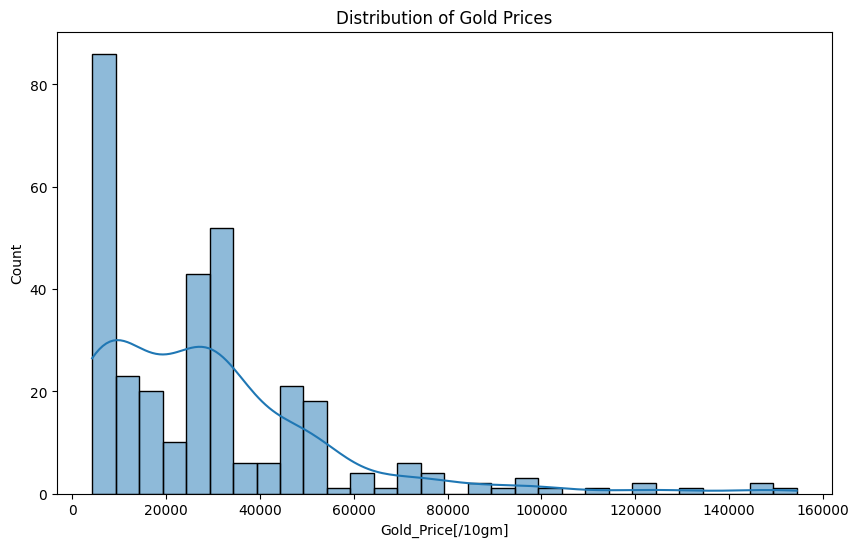

In [14]:
plt.figure(figsize = (10,6))

sns.histplot(
    df['Gold_Price[/10gm]'],
    bins=30,
    kde=True
)
plt.title("Distribution of Gold Prices")
plt.show()

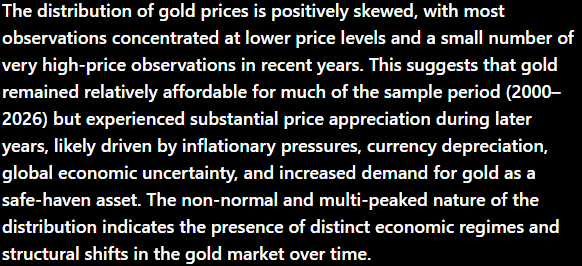

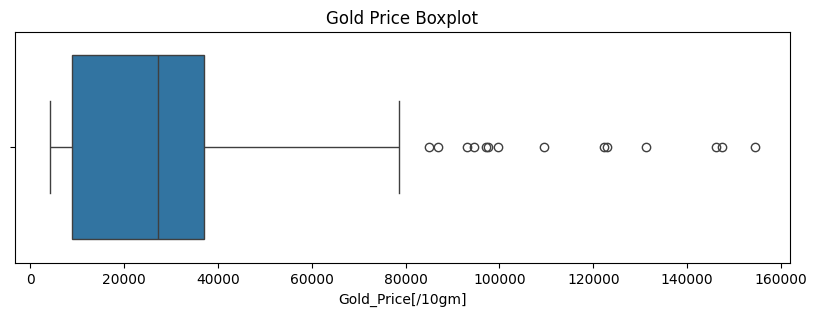

In [15]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df['Gold_Price[/10gm]']
)

plt.title("Gold Price Boxplot")
plt.show()

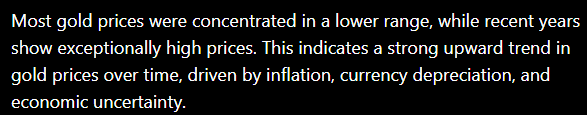

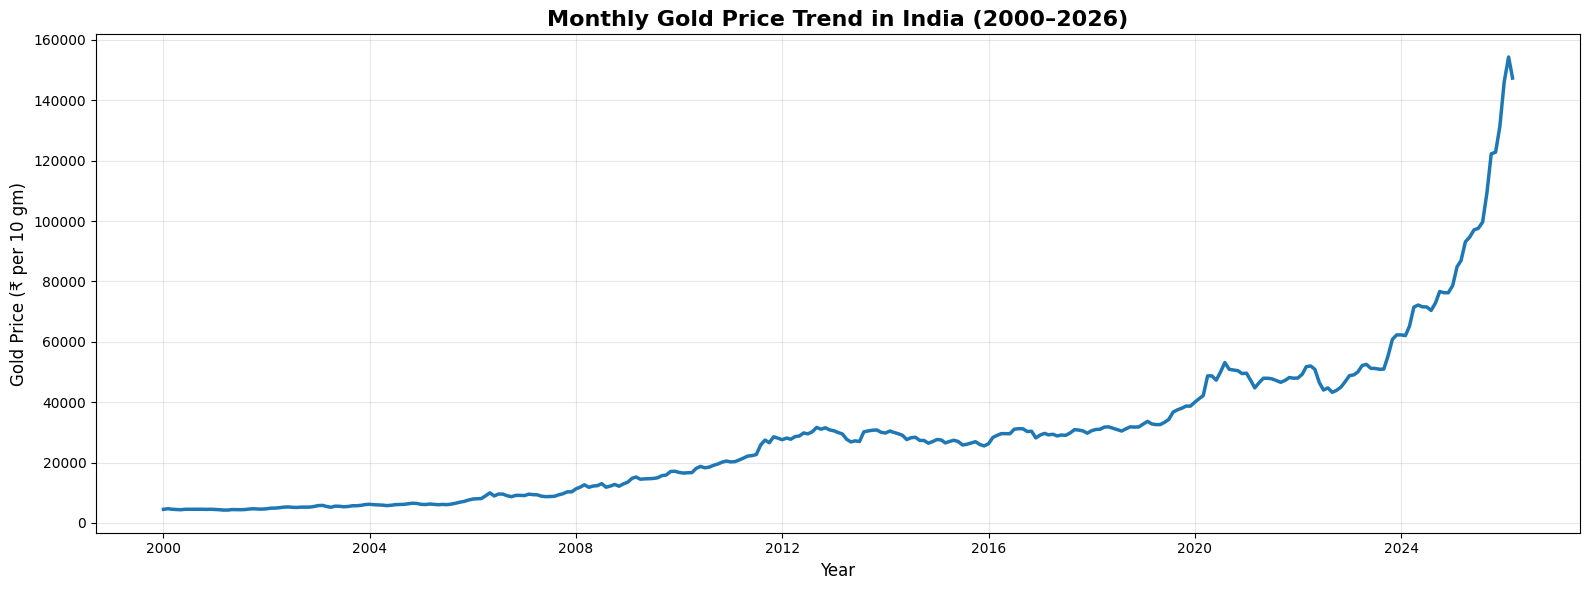

In [19]:
plt.figure(figsize=(16,6))

plt.plot(
    df['Date'],
    df['Gold_Price[/10gm]'],
    linewidth=2.5
)

plt.title(
    'Monthly Gold Price Trend in India (2000–2026)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Gold Price (₹ per 10 gm)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

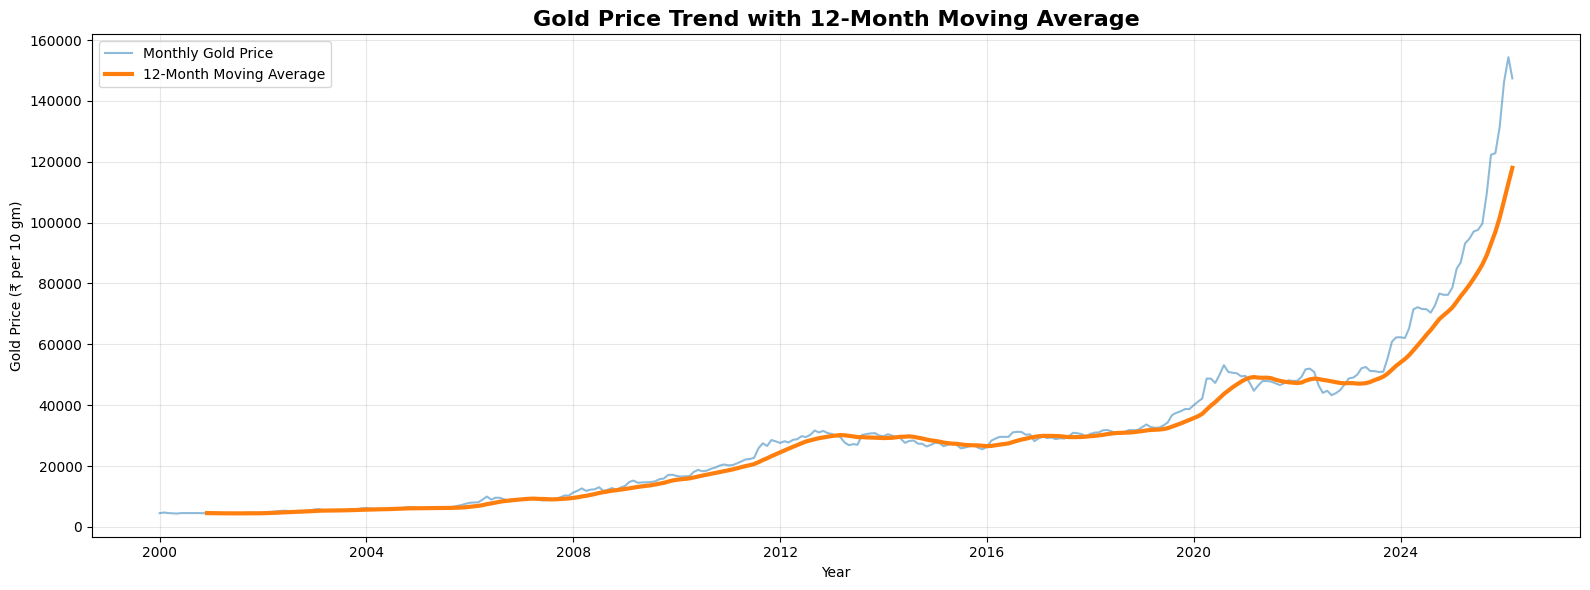

In [20]:
df['Gold_MA_12'] = (
    df['Gold_Price[/10gm]']
    .rolling(12)
    .mean()
)

plt.figure(figsize=(16,6))

plt.plot(
    df['Date'],
    df['Gold_Price[/10gm]'],
    alpha=0.5,
    label='Monthly Gold Price'
)

plt.plot(
    df['Date'],
    df['Gold_MA_12'],
    linewidth=3,
    label='12-Month Moving Average'
)

plt.title(
    'Gold Price Trend with 12-Month Moving Average',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Gold Price (₹ per 10 gm)')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Monthly Gold_Returns**

In [17]:
df['Gold_Return_%'] = (
    df['Gold_Price[/10gm]']
    .pct_change()
    *100
)

In [18]:
df

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM,Gold_Return_%
0,2000-01-01,2945.00,11.50,4510.75,---,43.59,---,---,---,---,NaN
1,2000-02-01,3104.00,11.50,4712.25,---,43.65,---,---,---,---,4.47
2,2000-03-01,2974.00,11.50,4541.90,---,43.64,---,---,---,---,-3.62
3,2000-04-01,2895.00,11.50,4462.06,---,43.68,---,---,---,---,-1.76
4,2000-05-01,2851.00,11.50,4371.14,---,44.08,---,---,---,---,-2.04
...,...,...,...,...,...,...,...,...,...,...,...
310,2025-11-01,106740.00,28.30,122834.00,408.40,88.84,5.50,197.90,0.71,0.30,0.44
311,2025-12-01,111262.00,28.30,131322.55,433.90,90.04,5.25,198,1.33,0.05,6.91
312,2026-01-01,126904.00,28.30,146169.80,---,90.90,5.25,---,2.38,0,11.31
313,2026-02-01,131630.00,28.30,154370.40,---,90.75,5.25,---,2.86,0,5.61


In [22]:
df['Gold_Return_%'].describe()

,Gold_Return_%
count,314.00
mean,1.18
std,3.71
min,-10.27
25%,-1.16
50%,0.77
75%,3.07
max,15.51


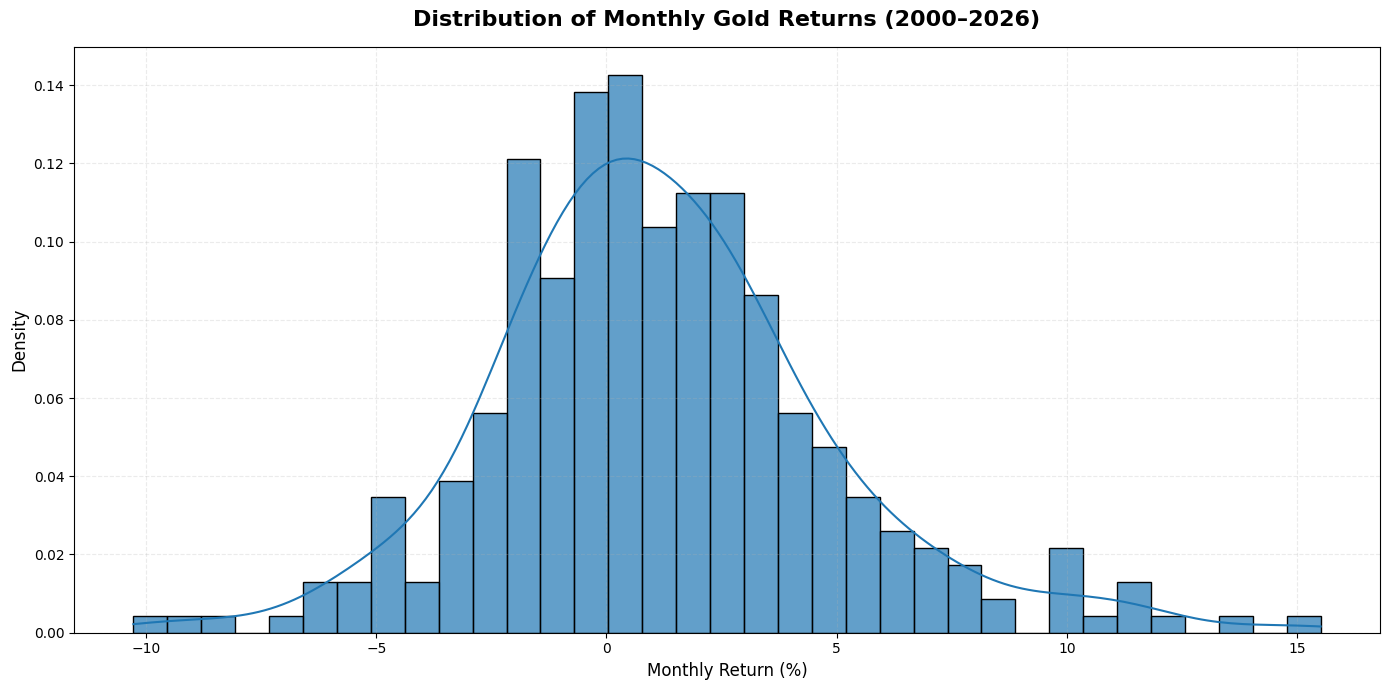

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.histplot(
    data=df,
    x='Gold_Return_%',
    bins=35,
    kde=True,
    stat='density',
    alpha=0.7
)

plt.title(
    'Distribution of Monthly Gold Returns (2000–2026)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Monthly Return (%)',
    fontsize=12
)

plt.ylabel(
    'Density',
    fontsize=12
)

plt.grid(
    alpha=0.25,
    linestyle='--'
)

plt.tight_layout()

plt.show()

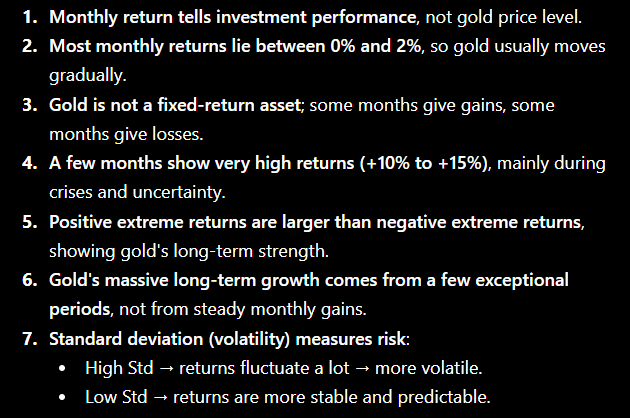

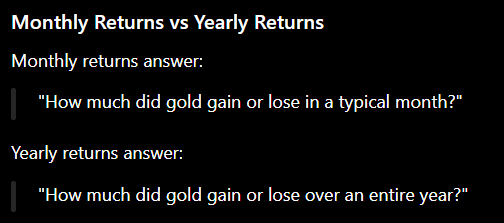

# **Yearly Gold_returns**

In [24]:
df_yearly = df.copy()

df_yearly['Year'] = df_yearly['Date'].dt.year

In [25]:
df_yearly = (
    df_yearly
    .groupby('Year')
    ['Gold_Price[/10gm]']
    .last()
    .reset_index()
)

In [26]:
df_yearly

,Year,Gold_Price[/10gm]
0,2000,4544.00
1,2001,4578.42
2,2002,5437.38
3,2003,6093.64
4,2004,6439.57
5,2005,7582.27
6,2006,9135.53
7,2007,10290.79
8,2008,12923.86
9,2009,17129.57


In [27]:
df_yearly['Yearly_Return_%'] = (
    df_yearly['Gold_Price[/10gm]']
    .pct_change()
    *100
)

In [28]:
df_yearly['Yearly_Return_%'] = (
    df_yearly['Yearly_Return_%']
    .round(2)
)

In [29]:
df_yearly

,Year,Gold_Price[/10gm],Yearly_Return_%
0,2000,4544.00,NaN
1,2001,4578.42,0.76
2,2002,5437.38,18.76
3,2003,6093.64,12.07
4,2004,6439.57,5.68
5,2005,7582.27,17.74
6,2006,9135.53,20.49
7,2007,10290.79,12.65
8,2008,12923.86,25.59
9,2009,17129.57,32.54


In [30]:
df_yearly['Yearly_Return_%'].describe()

,Yearly_Return_%
count,26.00
mean,15.44
std,17.14
min,-10.29
25%,5.57
50%,12.45
75%,22.25
max,72.20


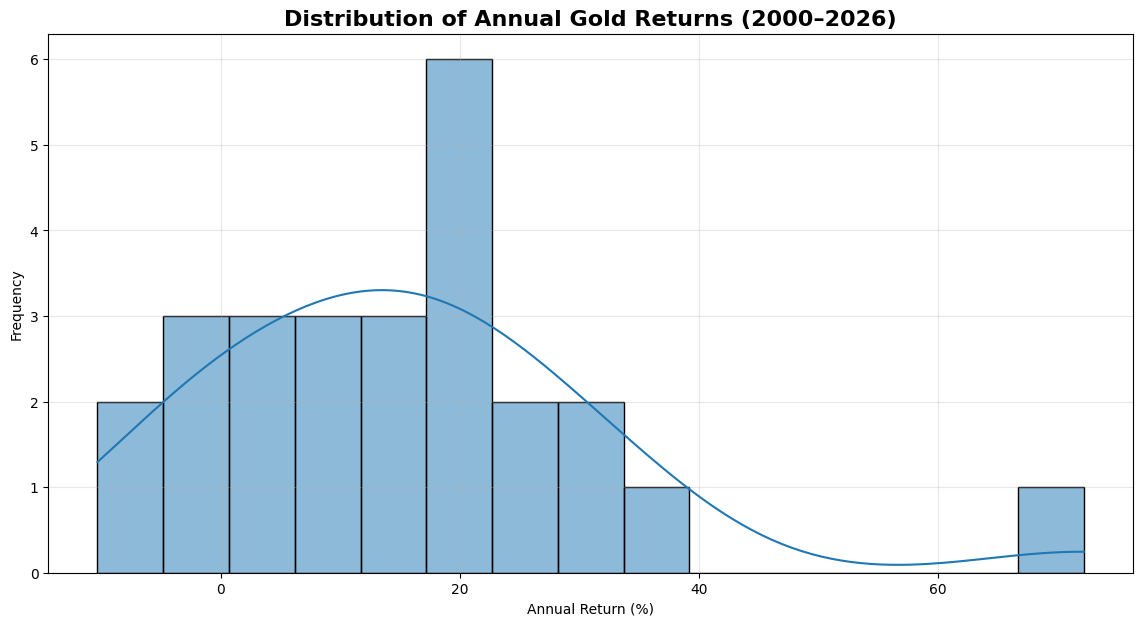

In [31]:
plt.figure(figsize=(14,7))

sns.histplot(
    df_yearly['Yearly_Return_%'],
    bins=15,
    kde=True
)

plt.title(
    'Distribution of Annual Gold Returns (2000–2026)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Annual Return (%)')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)

plt.show()

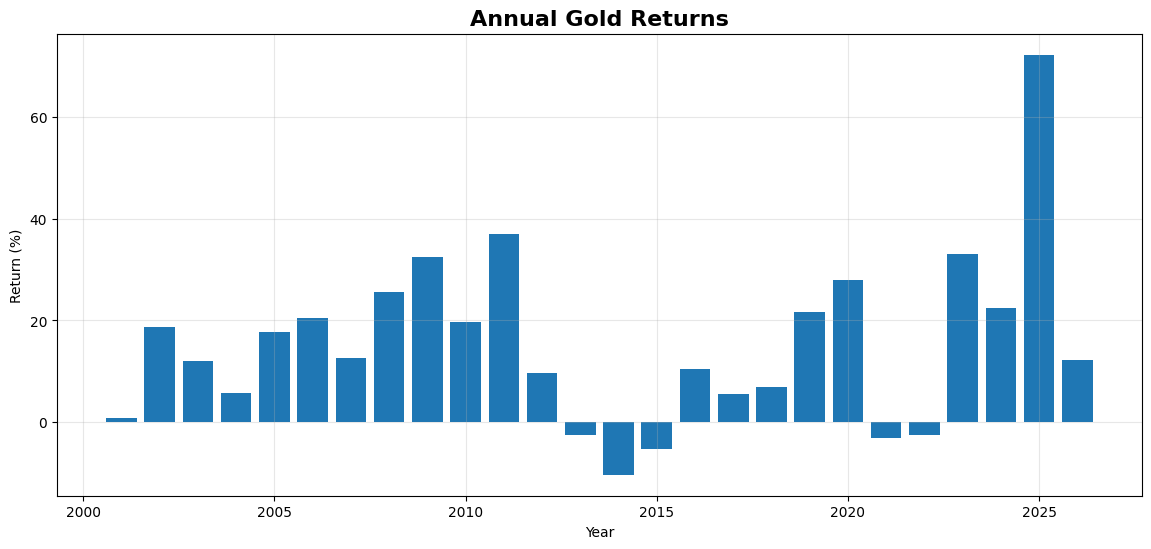

In [32]:
plt.figure(figsize=(14,6))

plt.bar(
    df_yearly['Year'],
    df_yearly['Yearly_Return_%']
)

plt.title(
    'Annual Gold Returns',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Return (%)')

plt.grid(alpha=0.3)

plt.show()

In [33]:
yearly_volatility = (
    df_yearly['Yearly_Return_%']
    .std()
)

print(
    f"Annual Return Volatility = {yearly_volatility:.2f}%"
)

Annual Return Volatility = 17.14%


In [34]:
print(df['Gold_Return_%'].std())
print(df_yearly['Yearly_Return_%'].std())

3.7067745025066547
17.139364354069215


In [35]:
monthly_mean = df['Gold_Return_%'].mean()
monthly_std  = df['Gold_Return_%'].std()

yearly_mean = df_yearly['Yearly_Return_%'].mean()
yearly_std  = df_yearly['Yearly_Return_%'].std()

In [37]:
#coefficient of variation

monthly_cv = monthly_std / monthly_mean
yearly_cv = yearly_std / yearly_mean

print(f"Monthly CV = {monthly_cv:.2f}")
print(f"Yearly CV = {yearly_cv:.2f}")

Monthly CV = 3.13
Yearly CV = 1.11


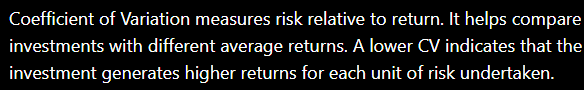

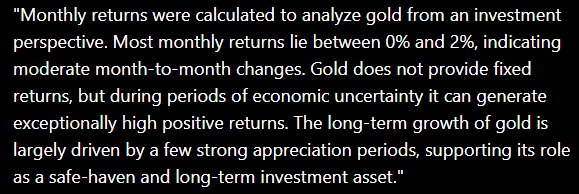

# **CAGR(Compound Annual Growth Rate)**

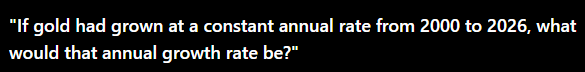

In [38]:
start_price = df['Gold_Price[/10gm]'].iloc[0]

end_price = df['Gold_Price[/10gm]'].iloc[-1]

years = (
    df['Date'].max()
    -
    df['Date'].min()
).days / 365.25

cagr = (
    (end_price / start_price)
    ** (1 / years)
    - 1
) * 100

print(f"CAGR = {cagr:.2f}%")

CAGR = 14.26%


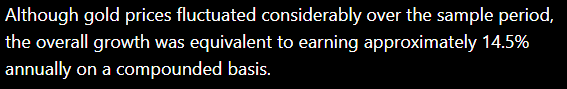

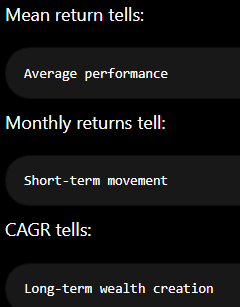
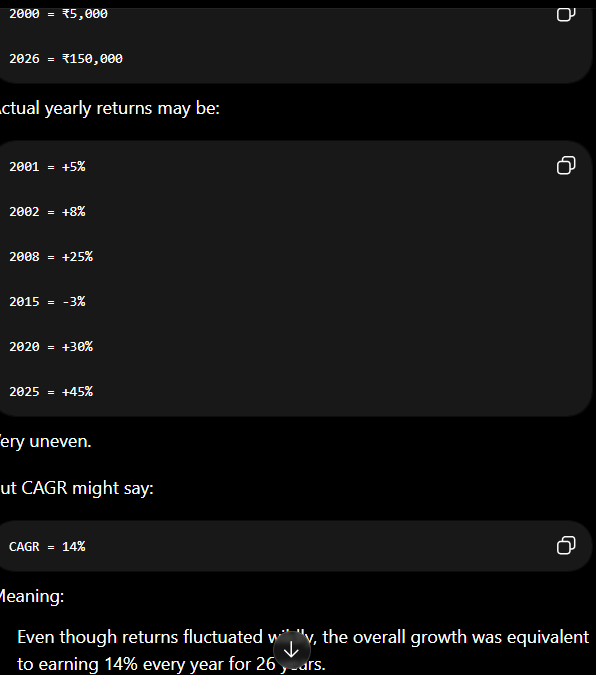

# **5 year Window Analysis**

In [41]:
windows = [
    ('2000-01-01', '2004-12-31', '2000-2004'),
    ('2005-01-01', '2009-12-31', '2005-2009'),
    ('2010-01-01', '2014-12-31', '2010-2014'),
    ('2015-01-01', '2019-12-31', '2015-2019'),
    ('2020-01-01', '2025-12-31', '2020-2025')
]

In [42]:
window_stats = []

for start, end, label in windows:

    temp = df[
        (df['Date'] >= start) &
        (df['Date'] <= end)
    ]

    first_price = temp['Gold_Price[/10gm]'].iloc[0]
    last_price  = temp['Gold_Price[/10gm]'].iloc[-1]

    growth = (
        (last_price - first_price)
        /
        first_price
    ) * 100

    years = 5

    cagr = (
        (last_price / first_price)
        ** (1 / years)
        - 1
    ) * 100

    window_stats.append({
        'Window': label,
        'Mean': temp['Gold_Price[/10gm]'].mean(),
        'Median': temp['Gold_Price[/10gm]'].median(),
        'Std': temp['Gold_Price[/10gm]'].std(),
        'Min': temp['Gold_Price[/10gm]'].min(),
        'Max': temp['Gold_Price[/10gm]'].max(),
        'Growth_%': growth,
        'CAGR_%': cagr
    })

window_stats_df = pd.DataFrame(window_stats)

window_stats_df.round(2)

,Window,Mean,Median,Std,Min,Max,Growth_%,CAGR_%
0,2000-2004,5169.46,5188.91,667.92,4264.17,6542.94,42.76,7.38
1,2005-2009,10435.59,9550.07,3119.53,6034.55,17129.57,178.60,22.74
2,2010-2014,25887.49,27600.00,4742.72,16515.83,31651.39,61.09,10.01
3,2015-2019,30458.59,30418.48,3113.70,25515.91,38718.50,39.98,6.96
4,2020-2025,61254.22,50910.78,21262.02,39987.74,131322.55,228.41,26.85


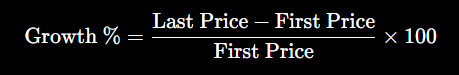

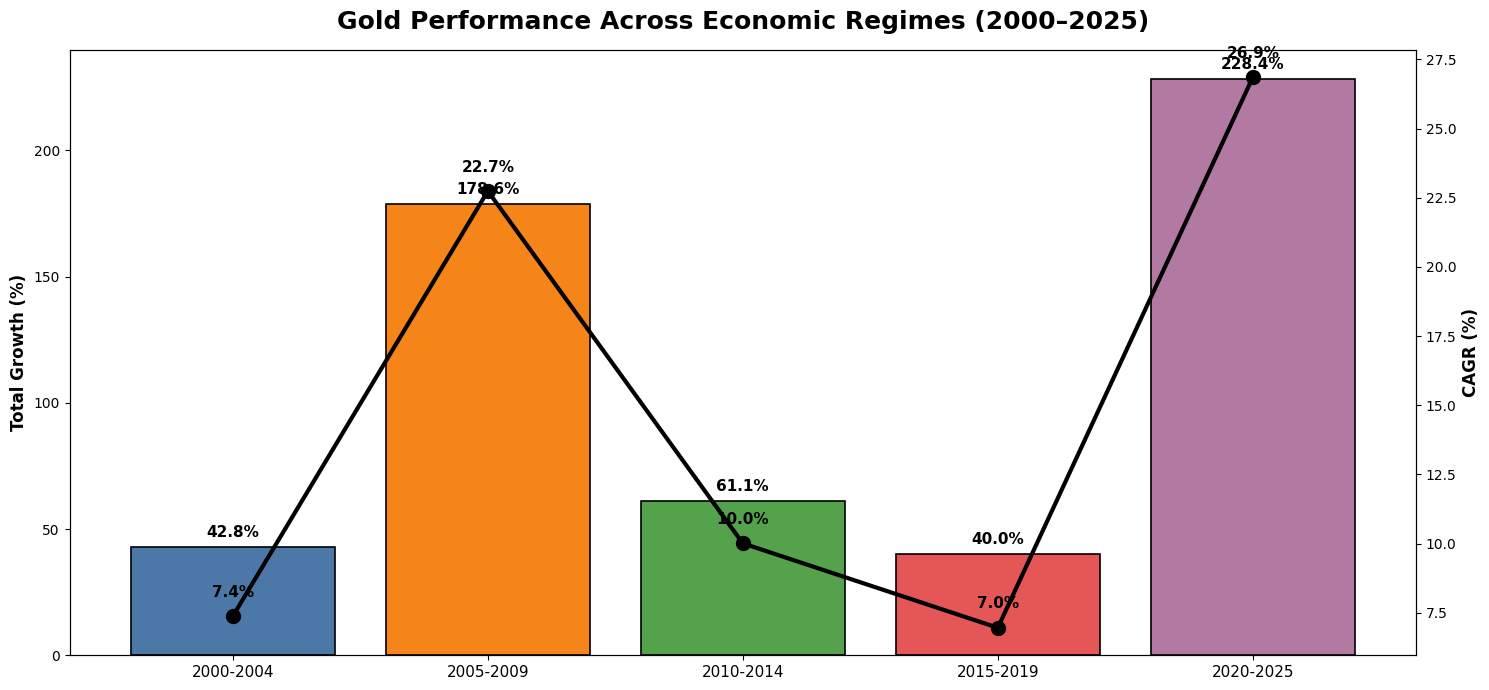

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Custom colors for each economic regime
colors = [
    '#4C78A8',   # 2000-04
    '#F58518',   # 2005-09
    '#54A24B',   # 2010-14
    '#E45756',   # 2015-19
    '#B279A2'    # 2020-25
]

fig, ax1 = plt.subplots(figsize=(15,7))

x = np.arange(len(window_stats_df))

bars = ax1.bar(
    x,
    window_stats_df['Growth_%'],
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# Growth labels
for bar in bars:
    h = bar.get_height()

    ax1.text(
        bar.get_x()+bar.get_width()/2,
        h+4,
        f'{h:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax1.set_ylabel(
    'Total Growth (%)',
    fontsize=12,
    fontweight='bold'
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    window_stats_df['Window'],
    fontsize=11
)

# CAGR line
ax2 = ax1.twinx()

ax2.plot(
    x,
    window_stats_df['CAGR_%'],
    color='black',
    marker='o',
    markersize=10,
    linewidth=3
)

# CAGR labels
for i, val in enumerate(window_stats_df['CAGR_%']):
    ax2.text(
        i,
        val+0.7,
        f'{val:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'

    )

ax2.set_ylabel(
    'CAGR (%)',
    fontsize=12,
    fontweight='bold'
)

plt.title(
    'Gold Performance Across Economic Regimes (2000–2025)',
    fontsize=18,
    fontweight='bold',
    pad=15
)


plt.tight_layout()

plt.show()

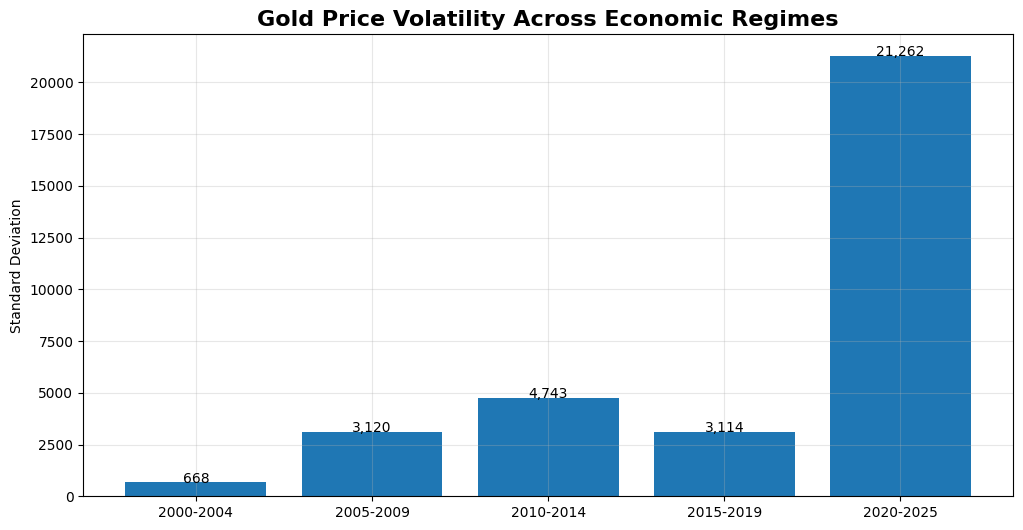

In [51]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    window_stats_df['Window'],
    window_stats_df['Std']
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center'
    )

plt.title(
    'Gold Price Volatility Across Economic Regimes',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Standard Deviation')
plt.grid(alpha=0.3)

plt.show()

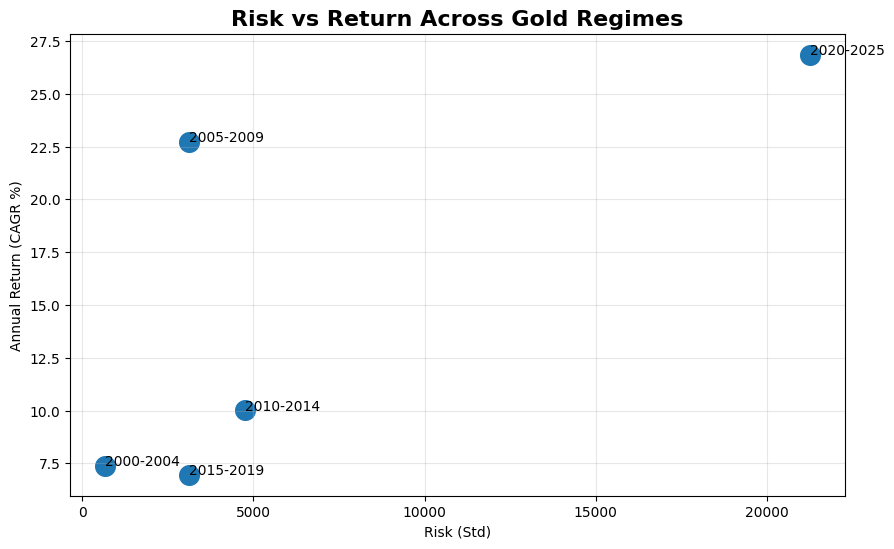

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(
    window_stats_df['Std'],
    window_stats_df['CAGR_%'],
    s=200
)

for i in range(len(window_stats_df)):
    plt.annotate(
        window_stats_df['Window'][i],
        (
            window_stats_df['Std'][i],
            window_stats_df['CAGR_%'][i]
        )
    )

plt.xlabel('Risk (Std)')
plt.ylabel('Annual Return (CAGR %)')
plt.title(
    'Risk vs Return Across Gold Regimes',
    fontsize=16,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.show()

In [44]:
df['Gold_Return_%'] = (
    df['Gold_Price[/10gm]']
    .pct_change()
    *100
)

In [45]:
window_return_stats = []

for start, end, label in windows:

    temp = df[
        (df['Date'] >= start) &
        (df['Date'] <= end)
    ]

    window_return_stats.append({

        'Window': label,

        'Avg_Return_%':
        temp['Gold_Return_%'].mean(),

        'Median_Return_%':
        temp['Gold_Return_%'].median(),

        'Volatility_%':
        temp['Gold_Return_%'].std(),

        'Best_Month_%':
        temp['Gold_Return_%'].max(),

        'Worst_Month_%':
        temp['Gold_Return_%'].min()

    })

window_return_df = pd.DataFrame(
    window_return_stats
)

window_return_df.round(2)

,Window,Avg_Return_%,Median_Return_%,Volatility_%,Best_Month_%,Worst_Month_%
0,2000-2004,0.64,0.33,2.70,7.18,-6.18
1,2005-2009,1.75,1.43,4.62,11.36,-10.27
2,2010-2014,0.82,0.64,3.61,14.04,-6.08
3,2015-2019,0.64,0.66,2.57,7.98,-7.28
4,2020-2025,1.79,1.14,4.14,15.51,-8.59


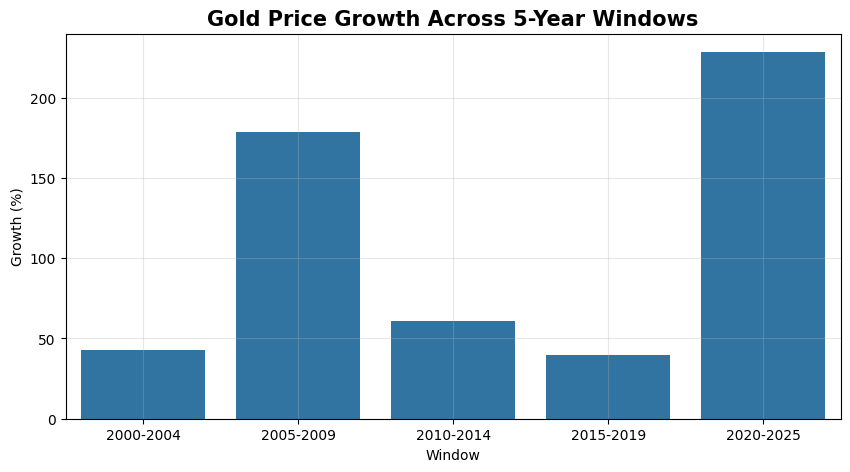

In [46]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=window_stats_df,
    x='Window',
    y='Growth_%'
)

plt.title(
    'Gold Price Growth Across 5-Year Windows',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('Growth (%)')

plt.grid(alpha=0.3)

plt.show()

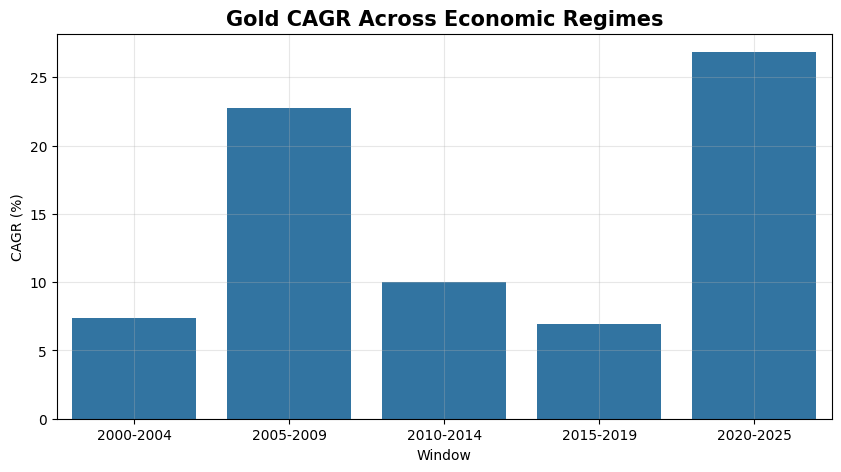

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=window_stats_df,
    x='Window',
    y='CAGR_%'
)

plt.title(
    'Gold CAGR Across Economic Regimes',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('CAGR (%)')

plt.grid(alpha=0.3)

plt.show()

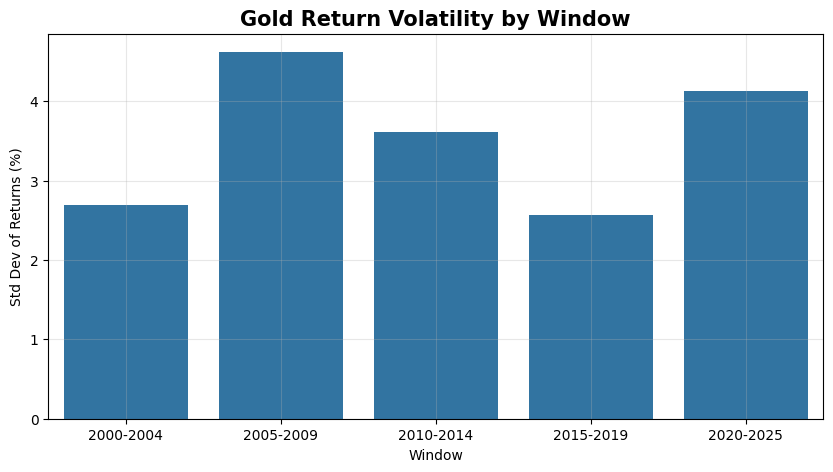

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=window_return_df,
    x='Window',
    y='Volatility_%'
)

plt.title(
    'Gold Return Volatility by Window',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('Std Dev of Returns (%)')

plt.grid(alpha=0.3)

plt.show()

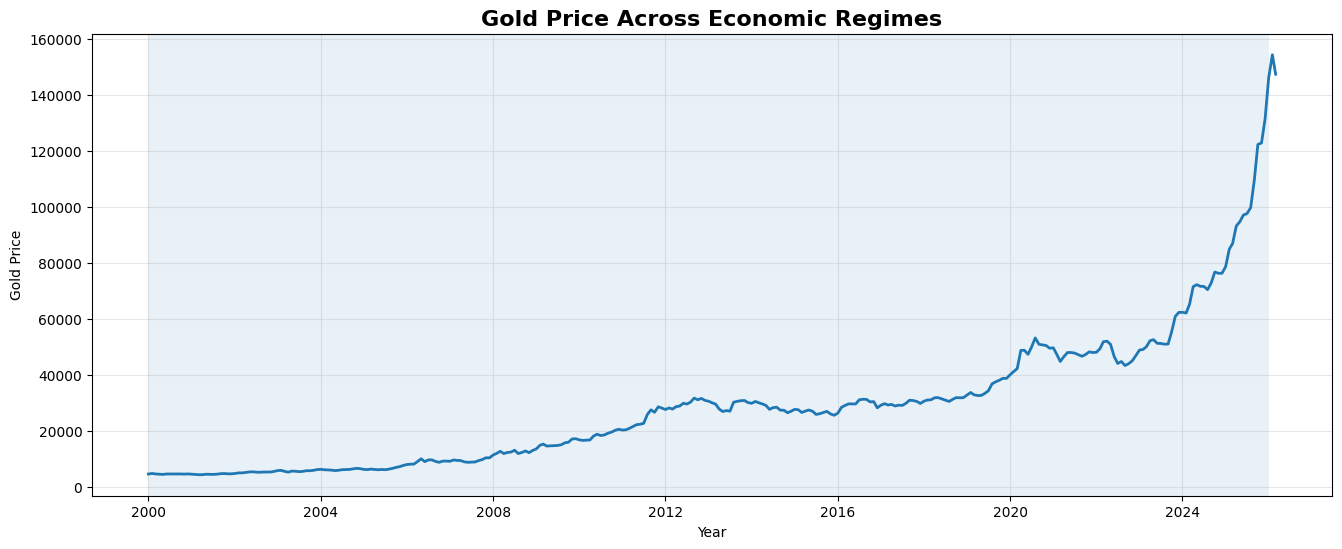

In [49]:
plt.figure(figsize=(16,6))

plt.plot(
    df['Date'],
    df['Gold_Price[/10gm]'],
    linewidth=2
)

for start, end, label in windows:

    plt.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        alpha=0.1
    )

plt.title(
    'Gold Price Across Economic Regimes',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Gold Price')

plt.grid(alpha=0.3)

plt.show()